In [16]:
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
data = pd.read_csv('dataset.csv')
data.head()

,NumHAcceptors,NumHDonors,alkyl_num,frag_sym,HOMO_calc,LUMO_calc,dipole,MPI,surface_min,surface_max,...,anchor_end_PO,anchor_end_SA,anchor_end_SH,anchor_end_SiO,MetalOxide_ITO,MetalOxide_NiOx,MetalOxide_SnO2,MetalOxide_TiO2,MetalOxide_ZnO,PCE
0,2,2,2,1,-5.665071,-1.022318,1.975439,11.42494,-38.62844,53.933991,...,0,0,0,0,0,1,0,0,0,22.40
1,4,2,2,1,-5.146211,-1.007550,1.467697,12.11600,-39.79595,52.674270,...,0,0,0,0,0,1,0,0,0,21.00
2,4,2,4,1,-5.182687,-1.386859,2.954174,12.05384,-40.46879,51.108000,...,0,0,0,0,0,1,0,0,0,25.60
3,3,1,0,0,-8.070575,-1.975575,6.131034,17.92665,-35.95829,45.147690,...,0,1,0,0,0,0,0,1,0,16.54
4,3,1,0,0,-7.655580,-1.919355,3.424702,15.53109,-31.70790,57.597300,...,0,1,0,0,0,0,0,1,0,16.88


In [17]:
x = data.iloc[:,:-1]
y = data.iloc[:,-1] - data['control_PCE']
from sklearn.model_selection import ShuffleSplit,train_test_split, GridSearchCV, KFold
cv = ShuffleSplit(n_splits=10, test_size=0.2, random_state=42)
x_train0, x_test0, y_train, y_test = train_test_split(x, y, test_size=0.15, random_state=0)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train0)
x_test = scaler.transform(x_test0)

In [18]:
import matplotlib.ticker as mticker
import matplotlib
from matplotlib.backends import backend_pdf

plt.rcParams.update({
    'font.size': 8,
    'axes.titlesize': 8,
    'axes.labelsize': 8,
    'lines.linewidth': 0.75,
    'font.family': 'Helvetica',
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'svg.fonttype': 'none'
})
other_params={'objective': 'reg:squarederror',
              'seed': 0,
    }

In [19]:
# Xgboost
import xgboost as xgb
import optuna
from optuna.samplers import TPESampler
def objective(trial):
    params = {
            'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.04),
            'n_estimators': trial.suggest_int('n_estimators', 100, 300),
            'max_depth': trial.suggest_int('max_depth', 2, 5),
            'min_child_weight': trial.suggest_int('min_child_weight', 2, 5),
            'subsample': trial.suggest_float('subsample', 0.3, 0.7),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 0.6),
            'gamma': trial.suggest_float('gamma', 0.1, 0.4),
            'reg_alpha': trial.suggest_float('reg_alpha', 0.1, 0.4),
            'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 0.4),
            'early_stopping_rounds': 50,
        }
    params.update(other_params)
    model = xgb.sklearn.XGBRegressor(**params)
    model.fit(x_train, y_train,
                eval_set=[(x_test, y_test)],
                verbose=0)
    pred = model.predict(x_test)
    return -mean_squared_error(y_test, pred)

sampler = TPESampler(seed=0)
study = optuna.create_study(direction='maximize', sampler=sampler)
study.optimize(objective, n_trials=100, show_progress_bar=True)
model = xgb.sklearn.XGBRegressor(**other_params)
best_params = study.best_params
best_params.update(other_params)
xgb_model = xgb.sklearn.XGBRegressor(**best_params)
xgb_model.fit(x_train, y_train)

print(f"Best CV score: {study.best_value}")
print(f"Best params: {study.best_params}")
print(f"RMSE_train: {np.sqrt(mean_squared_error(y_train, xgb_model.predict(x_train)))}")
print(f"r_train: {stats.pearsonr(y_train, xgb_model.predict(x_train))[0]}")
print(f"RMSE_test: {np.sqrt(mean_squared_error(y_test, xgb_model.predict(x_test)))}")
print(f"r_test: {stats.pearsonr(y_test, xgb_model.predict(x_test))[0]}")

[I 2026-04-03 15:30:13,623] A new study created in memory with name: no-name-10d6dc16-f5eb-4dcb-9521-f9821c46c0f7
Best trial: 0. Best value: -0.533333:   6%|▌         | 6/100 [00:00<00:03, 27.66it/s]

[I 2026-04-03 15:30:13,685] Trial 0 finished with value: -0.5333330767456589 and parameters: {'learning_rate': 0.02420847263745637, 'n_estimators': 243, 'max_depth': 4, 'min_child_weight': 4, 'subsample': 0.46946191973556184, 'colsample_bytree': 0.4937682339199968, 'gamma': 0.23127616337880777, 'reg_alpha': 0.367531900234624, 'reg_lambda': 0.38909882815030883}. Best is trial 0 with value: -0.5333330767456589.
[I 2026-04-03 15:30:13,747] Trial 1 finished with value: -0.5696100623421055 and parameters: {'learning_rate': 0.01842045315890222, 'n_estimators': 259, 'max_depth': 4, 'min_child_weight': 4, 'subsample': 0.6702386553170644, 'colsample_bytree': 0.32131081745936607, 'gamma': 0.12613878991046223, 'reg_alpha': 0.10606551923209773, 'reg_lambda': 0.3497859536643815}. Best is trial 0 with value: -0.5333330767456589.
[I 2026-04-03 15:30:13,785] Trial 2 finished with value: -0.5533008555657856 and parameters: {'learning_rate': 0.03223548628324477, 'n_estimators': 274, 'max_depth': 5, 'min

Best trial: 0. Best value: -0.533333:  11%|█         | 11/100 [00:00<00:02, 30.75it/s]

[I 2026-04-03 15:30:13,887] Trial 6 finished with value: -0.5974282749513476 and parameters: {'learning_rate': 0.012310686463319214, 'n_estimators': 132, 'max_depth': 4, 'min_child_weight': 3, 'subsample': 0.4865243091425225, 'colsample_bytree': 0.3733276776004808, 'gamma': 0.14769087509365592, 'reg_alpha': 0.13311254234929154, 'reg_lambda': 0.29689887683958205}. Best is trial 0 with value: -0.5333330767456589.
[I 2026-04-03 15:30:13,912] Trial 7 finished with value: -0.6449126666682127 and parameters: {'learning_rate': 0.009836403297201483, 'n_estimators': 139, 'max_depth': 3, 'min_child_weight': 5, 'subsample': 0.3388405103172245, 'colsample_bytree': 0.5513834722496411, 'gamma': 0.12882952236818893, 'reg_alpha': 0.3929378395040187, 'reg_lambda': 0.2405953604943105}. Best is trial 0 with value: -0.5333330767456589.
[I 2026-04-03 15:30:13,942] Trial 8 finished with value: -0.5758313229333196 and parameters: {'learning_rate': 0.0391866380866618, 'n_estimators': 221, 'max_depth': 4, 'min

Best trial: 0. Best value: -0.533333:  17%|█▋        | 17/100 [00:00<00:03, 25.99it/s]

...

[I 2026-04-03 15:30:17,559] Trial 88 finished with value: -0.6579359115461558 and parameters: {'learning_rate': 0.025084303545826893, 'n_estimators': 272, 'max_depth': 5, 'min_child_weight': 5, 'subsample': 0.5786990892383932, 'colsample_bytree': 0.5494800135115208, 'gamma': 0.1193878257142549, 'reg_alpha': 0.32151840410622723, 'reg_lambda': 0.2216000585193538}. Best is trial 81 with value: -0.5138855640175941.
[I 2026-04-03 15:30:17,619] Trial 89 finished with value: -0.5716219198938441 and parameters: {'learning_rate': 0.019641760693614407, 'n_estimators': 128, 'max_depth': 4, 'min_child_weight': 4, 'subsample': 0.5210213238937549, 'colsample_bytree': 0.5065275617658009, 'gamma': 0.2844290623135873, 'reg_alpha': 0.3339752478902486, 'reg_lambda': 0.11814745022320364}. Best is trial 81 with value: -0.5138855640175941.
[I 2026-04-03 15:30:17,661] Trial 90 finished with value: -0.5807802973948424 and parameters: {'learning_rate': 0.03682424038250698, 'n_estimators': 227, 'max_depth': 5, 

Best trial: 96. Best value: -0.512626:  98%|█████████▊| 98/100 [00:04<00:00, 21.00it/s]

[I 2026-04-03 15:30:17,798] Trial 93 finished with value: -0.5793049485264031 and parameters: {'learning_rate': 0.02192676486817155, 'n_estimators': 100, 'max_depth': 5, 'min_child_weight': 5, 'subsample': 0.5126021661317957, 'colsample_bytree': 0.5394206786546059, 'gamma': 0.17886854121857904, 'reg_alpha': 0.16345892736782927, 'reg_lambda': 0.1405480702486672}. Best is trial 81 with value: -0.5138855640175941.
[I 2026-04-03 15:30:17,847] Trial 94 finished with value: -0.5889676411569424 and parameters: {'learning_rate': 0.037458252922384125, 'n_estimators': 295, 'max_depth': 5, 'min_child_weight': 5, 'subsample': 0.4492033350385741, 'colsample_bytree': 0.5561443638971509, 'gamma': 0.21007067899358803, 'reg_alpha': 0.18281299992031994, 'reg_lambda': 0.2554655587351625}. Best is trial 81 with value: -0.5138855640175941.
[I 2026-04-03 15:30:17,893] Trial 95 finished with value: -0.565854936744398 and parameters: {'learning_rate': 0.034602544202553695, 'n_estimators': 282, 'max_depth': 5,

Best trial: 96. Best value: -0.512626: 100%|██████████| 100/100 [00:04<00:00, 22.39it/s]


[I 2026-04-03 15:30:18,045] Trial 98 finished with value: -0.5642932302735004 and parameters: {'learning_rate': 0.033518052284416566, 'n_estimators': 160, 'max_depth': 5, 'min_child_weight': 3, 'subsample': 0.47851479994681084, 'colsample_bytree': 0.45462126898931954, 'gamma': 0.112882886490855, 'reg_alpha': 0.26703148306425406, 'reg_lambda': 0.3130620491555917}. Best is trial 96 with value: -0.5126260223535615.
[I 2026-04-03 15:30:18,089] Trial 99 finished with value: -0.5772638910073709 and parameters: {'learning_rate': 0.03598945965104113, 'n_estimators': 133, 'max_depth': 3, 'min_child_weight': 3, 'subsample': 0.4878783309078853, 'colsample_bytree': 0.5951423597462426, 'gamma': 0.15216573869426567, 'reg_alpha': 0.23406095752477749, 'reg_lambda': 0.278374554469025}. Best is trial 96 with value: -0.5126260223535615.
Best CV score: -0.5126260223535615
Best params: {'learning_rate': 0.038720219063009105, 'n_estimators': 146, 'max_depth': 5, 'min_child_weight': 3, 'subsample': 0.4805652

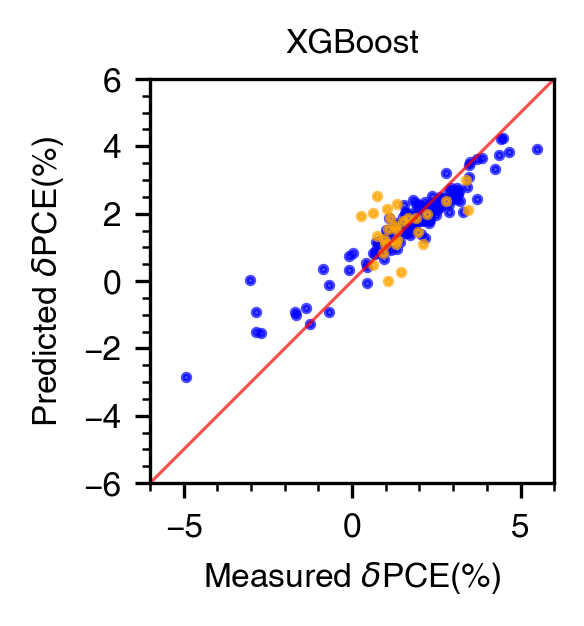

In [20]:
fig = plt.figure(dpi=300,figsize=(1.75,1.75))
ax = fig.add_subplot(111)
ax.scatter(y_train, xgb_model.predict(x_train), color='blue',alpha=0.7,s=3)
ax.scatter(y_test, xgb_model.predict(x_test), color='orange',alpha=0.7,s=3)
ax.plot([-6,6],[-6,6],'-r',alpha=0.7)
ax.set_aspect('equal')
ax.set_title('XGBoost')
ax.minorticks_on()
ax.xaxis.set_major_locator(mticker.MultipleLocator(5))
plt.xlabel(r'Measured $\delta$PCE(%)')
plt.ylabel(r'Predicted $\delta$PCE(%)')
plt.xlim(-6,6)
plt.ylim(-6,6)
plt.show()